In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

gen_results = np.load('/Users/isaaclee/Wildfire_Research/wildfire_results_ln/depth_4_epochs_10000_schedule_VE_sigma_5/generated_mean_std.npz')
gen_samples = np.load('/Users/isaaclee/Wildfire_Research/wildfire_results_ln/depth_4_epochs_10000_schedule_VE_sigma_5/generated_samples.npz')
real_samples = np.load('/Users/isaaclee/Wildfire_Research/wildfire_results_ln/depth_4_epochs_10000_schedule_VE_sigma_5/real_samples.npz')
conditional_inputs = np.load('/Users/isaaclee/Wildfire_Research/wildfire_results_ln/depth_4_epochs_10000_schedule_VE_sigma_5/conditional_inputs.npz')
training_testing_data = np.load('/Users/isaaclee/Wildfire_Research/data/training_testing_data_for_predicting_fire_area_from_ign_time_conditions.npy')
testing_data = training_testing_data[-1200:]

print(gen_results.files)
print(gen_samples.files)
print(real_samples.files)
print(conditional_inputs.files)

['array1', 'array2']
['arr_0']
['arr_0']
['arr_0']


In [12]:
scales = np.load('/Users/isaaclee/Wildfire_Research/wildfire_results_ln/x_scaling_factor.npz')
x_max = scales['x_max']

# unnormalize generated samples
gen_samples_raw = gen_samples['arr_0']
gen_samples_unnorm = np.exp(gen_samples_raw * x_max)

# unnormalize generated means
gen_means_raw = gen_results['array1']
gen_means_unnorm = np.exp(gen_means_raw * x_max)

# unnormalize real samples
real_samples_raw = real_samples['arr_0']
real_samples_unnorm = np.exp(real_samples_raw * x_max)

In [13]:
gen = gen_samples_unnorm.reshape(1200,1000)
stds = np.std(gen, axis=1)
real = real_samples_unnorm.flatten()
pred = gen_means_unnorm.flatten()

print(stds.shape)
print(real.shape)
print(pred.shape)

within_1_std = np.abs(real - pred) <= stds
proportions = within_1_std.astype(int)
print(np.mean(proportions))

print(np.mean(stds.flatten()))

(1200,)
(1200,)
(1200,)
0.27166666666666667
530.1190263596193


67926.46590108854
(1200000,)
(1200,)


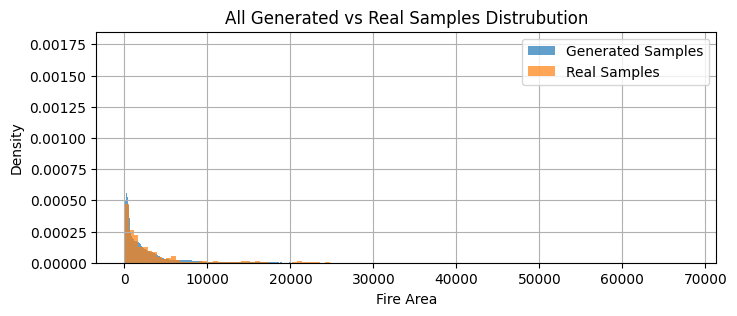

In [14]:
gen = gen_samples_unnorm.flatten()
real = real_samples_unnorm.flatten()

print(max(gen))

print(gen.shape)
print(real.shape)

plt.figure(figsize=(8,3))
plt.title('All Generated vs Real Samples Distrubution')
plt.hist(gen, bins='auto', alpha=0.7, label='Generated Samples', density=True)
plt.hist(real, bins='auto', alpha=0.7, label='Real Samples', density=True)
# plt.xlim((0,1))
# plt.ylim((0,30))
plt.legend()
plt.xlabel('Fire Area')
plt.ylabel('Density')
plt.grid(True)
plt.show()

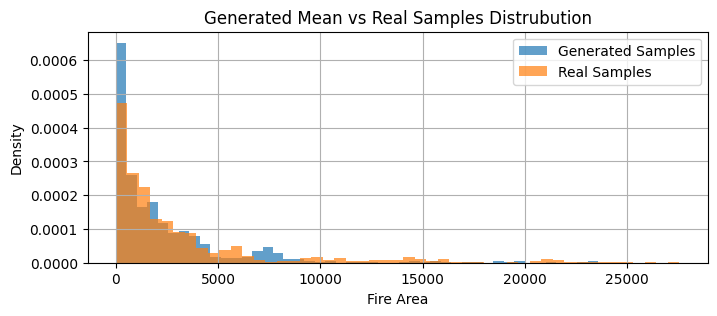

In [15]:
gen_mean = gen_means_unnorm.flatten()
plt.figure(figsize=(8,3))
plt.title('Generated Mean vs Real Samples Distrubution')
plt.hist(gen_mean, bins='auto', alpha=0.7, label='Generated Samples', density=True)
plt.hist(real, bins='auto', alpha=0.7, label='Real Samples', density=True)
plt.legend()
plt.xlabel('Fire Area')
plt.ylabel('Density')
plt.grid(True)
plt.show()

In [16]:
pred = gen_means_unnorm.flatten()
real = real_samples_unnorm.flatten()

print(pred.shape)
print(real.shape)

mae = np.mean(np.abs(real-pred))
print("Mean Absolute Error: " + str(mae))

normalized_mae = mae/np.mean(real)
print("Normalized Mean Absolute Error: " + str(normalized_mae))

mape = np.mean(np.abs(real-pred)/real)
print("Mean Absolute Percent Error: " + str(mape))

(1200,)
(1200,)
Mean Absolute Error: 1896.7962927491265
Normalized Mean Absolute Error: 0.5967365241667612
Mean Absolute Percent Error: 0.62653693212223


Text(0, 0.5, 'Percent error')

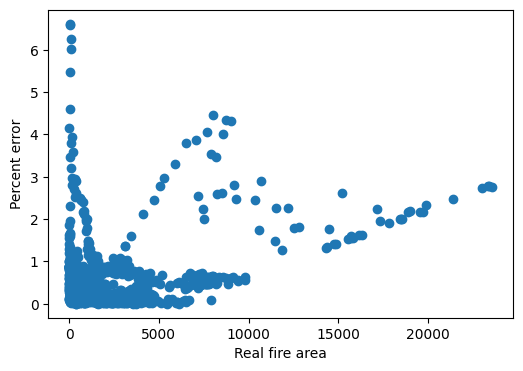

In [ ]:
percent_error = np.abs(real-pred)/real
fire_area = pred

plt.figure(figsize=(6,4))
plt.scatter(fire_area, percent_error)
plt.xlabel('Fire area')
plt.ylabel('Percent error')

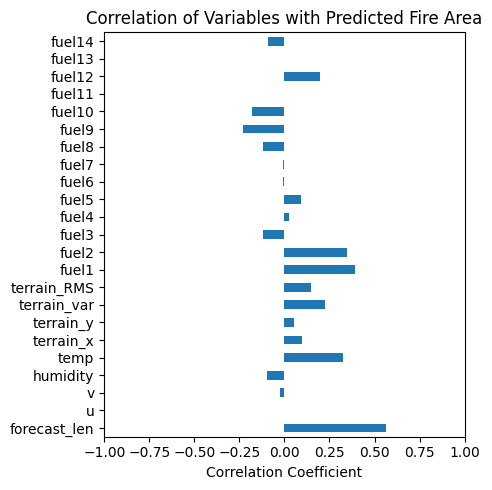

In [18]:
# update testing data, putting fire area predictions in fire area column
pred_testing_data = testing_data.copy()
pred_testing_data[:,0] = gen_means_unnorm.flatten()

col_names = ["fire_area", "forecast_len", "u", "v", "humidity", "temp", "terrain_x", "terrain_y", "terrain_var", "terrain_RMS", "fuel1", "fuel2", "fuel3", "fuel4", "fuel5", "fuel6", "fuel7", "fuel8", "fuel9", "fuel10", "fuel11", "fuel12","fuel13", "fuel14"]
pred_df = pd.DataFrame(pred_testing_data, columns=col_names)

pred_corr = pred_df.corr().iloc[0, 1:]

plt.figure(figsize=(5, 5))
pred_corr.plot(kind='barh')
plt.xlim(-1, 1)
plt.title("Correlation of Variables with Predicted Fire Area")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

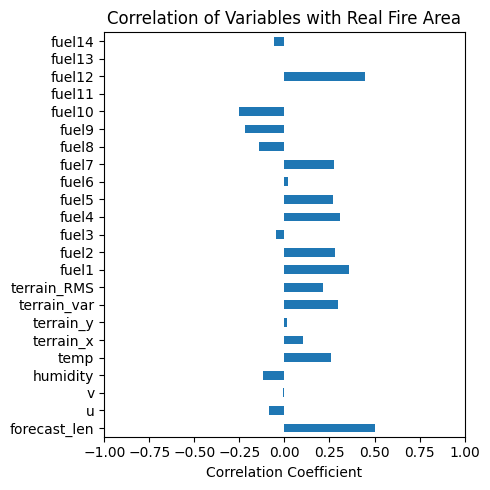

In [19]:
real_df = pd.DataFrame(testing_data, columns=col_names)

real_corr = real_df.corr().iloc[0, 1:]

plt.figure(figsize=(5, 5))
real_corr.plot(kind='barh')
plt.xlim(-1, 1)
plt.title("Correlation of Variables with Real Fire Area")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

In [20]:
x = 

SyntaxError: invalid syntax (3306000817.py, line 1)